<a href="https://colab.research.google.com/github/Faxsito/E2-Regresion-IA/blob/main/E2-Regresion/E2_Regresion_MRR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

# Evaluación 2 - Regresión Lineal

## Modelado Predictivo de Ingresos Recurrentes (MRR)
**Integrantes:** Constanza Tapia, Maura Gonzalez, Samuel Loyola, Felipe Riquelme


El objetivo de este trabajo es construir un modelo de regresión lineal que permita predecir el ingreso mensual recurrente del próximo trimestre de los clientes de SaaSFlow.

## 1. Carga y diagnóstico inicial de los datos

In [2]:
url = "https://raw.githubusercontent.com/Faxsito/E2-Regresion-IA/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv"

df = pd.read_csv(url)

df.head()

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


In [3]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

Cantidad de filas: 30000
Cantidad de columnas: 11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB


In [5]:
nulos = pd.DataFrame({
    "Cantidad_Nulos": df.isnull().sum(),
    "Porcentaje_Nulos": (df.isnull().sum() / len(df) * 100).round(2)
})

nulos

,Cantidad_Nulos,Porcentaje_Nulos
id_cliente,0,0.00
fecha_registro,0,0.00
sector_empresa,0,0.00
tamano_empresa,0,0.00
tickets_soporte,2464,8.21
promedio_sesiones_mes,1545,5.15
satisfaccion_nps,3597,11.99
duracion_contrato,0,0.00
gasto_mkt_asociado,0,0.00
pago_puntual,0,0.00


In [6]:
columnas_numericas = [
    "tickets_soporte",
    "promedio_sesiones_mes",
    "satisfaccion_nps",
    "gasto_mkt_asociado",
    "mrr_proximo_trimestre"
]

df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
tickets_soporte,27536.0,3.005121,1.734139,0.000000,2.000000,3.000000,4.000000,12.000000
promedio_sesiones_mes,28455.0,50.130595,45.058935,5.001555,18.086442,36.230789,67.451126,430.701397
satisfaccion_nps,26403.0,5.913911,2.312062,1.000000,4.000000,6.000000,8.000000,10.000000
gasto_mkt_asociado,30000.0,2551.090539,1416.112727,100.355894,1330.525002,2541.073850,3785.665164,4999.953843
mrr_proximo_trimestre,30000.0,710.926286,337.688948,50.000000,458.985000,642.595000,896.705000,3200.040000


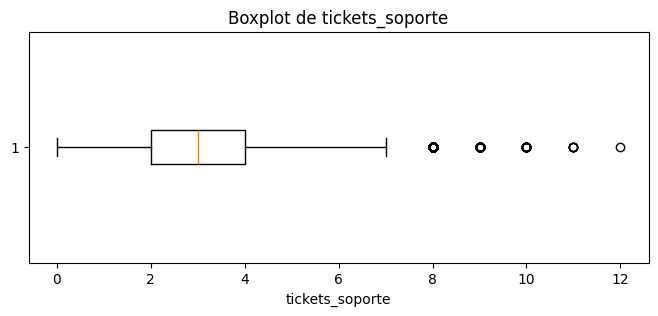

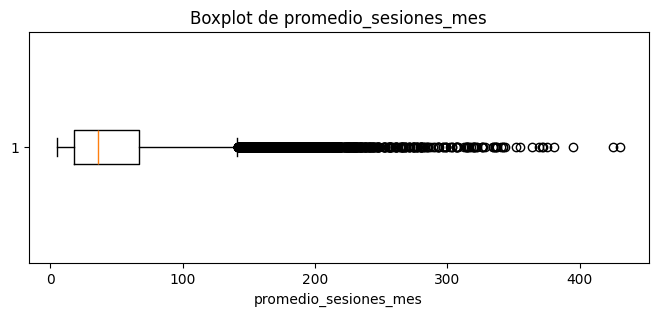

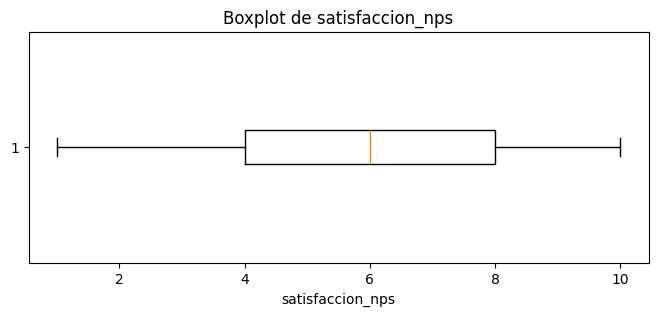

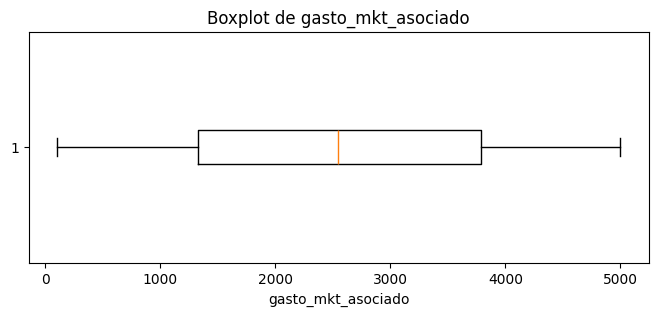

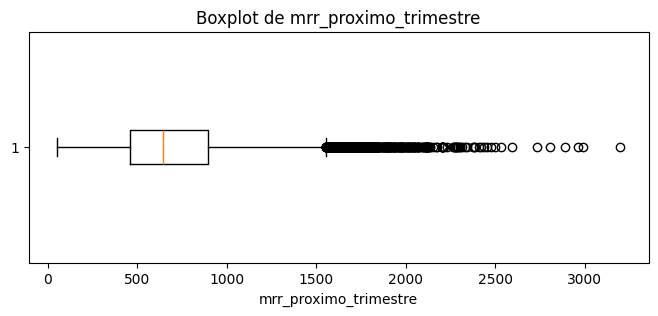

In [7]:
for columna in columnas_numericas:
    plt.figure(figsize=(8, 3))
    plt.boxplot(
    df[columna].dropna(),
    orientation="horizontal"
)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [8]:
for columna in columnas_numericas:
    datos = df[columna].dropna()

    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = datos[
        (datos < limite_inferior) |
        (datos > limite_superior)
    ]

    print(
        columna,
        "- Cantidad de outliers:",
        len(outliers)
    )

tickets_soporte - Cantidad de outliers: 328
promedio_sesiones_mes - Cantidad de outliers: 1367
satisfaccion_nps - Cantidad de outliers: 0
gasto_mkt_asociado - Cantidad de outliers: 0
mrr_proximo_trimestre - Cantidad de outliers: 607


### Interpretación del diagnóstico

El conjunto de datos contiene 30.000 registros y 11 variables. Se detectaron valores faltantes en `tickets_soporte` (8,21 %), `promedio_sesiones_mes` (5,15 %) y `satisfaccion_nps` (11,99 %). La variable objetivo `mrr_proximo_trimestre` no presenta valores faltantes.

Además, `fecha_registro` se encuentra inicialmente almacenada como tipo `object`, por lo que debe transformarse a una variable numérica antes de utilizarla en el modelo. Las variables categóricas también requieren codificación.

El análisis mediante diagramas de caja e IQR mostró valores atípicos principalmente en `promedio_sesiones_mes`, donde se detectaron 1.367 registros atípicos. Su media es superior a su mediana, lo que evidencia una distribución sesgada hacia valores altos.

Por esta razón, los valores faltantes de `promedio_sesiones_mes` se imputarán mediante la mediana, ya que es menos sensible a valores extremos. Para `tickets_soporte` y `satisfaccion_nps`, al ser variables discretas, se utilizará la moda.

También se detectaron valores atípicos en `mrr_proximo_trimestre`, pero no se eliminaron automáticamente, ya que un MRR elevado puede corresponder a un cliente real y no necesariamente a un dato incorrecto.

La imputación y las demás transformaciones se realizarán dentro del pipeline, de modo que sus parámetros se aprendan utilizando los datos de entrenamiento.

## 2. Preparación de los datos

Se separan las variables predictoras de la variable objetivo y posteriormente los datos se dividen en conjuntos de entrenamiento y prueba. El preprocesamiento será realizado dentro del pipeline para evitar fuga de información.

In [9]:
X = df.drop(columns=["mrr_proximo_trimestre"])
y = df["mrr_proximo_trimestre"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (24000, 10)
Datos de prueba: (6000, 10)


### Ingeniería de características

Para representar la antigüedad de cada cliente, `fecha_registro` se transforma en `antiguedad_dias`.

Se utiliza el 01-01-2026 como fecha de referencia, posterior al período de registros del dataset, para obtener una medida consistente y reproducible de la antigüedad.

In [10]:
FECHA_REFERENCIA = pd.Timestamp("2026-01-01")

def crear_antiguedad(datos):
    datos = datos.copy()

    fechas = pd.to_datetime(
        datos["fecha_registro"],
        errors="coerce"
    )

    datos["antiguedad_dias"] = (
        FECHA_REFERENCIA - fechas
    ).dt.days

    datos = datos.drop(
        columns=["fecha_registro", "id_cliente"]
    )

    return datos

In [11]:
pipeline_tickets = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent"))
])

In [12]:
pipeline_sesiones = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", RobustScaler())
])

In [13]:
pipeline_nps = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent"))
])

In [14]:
pipeline_continuas = Pipeline(steps=[
    ("escalado", RobustScaler())
])

In [15]:
pipeline_sector = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
pipeline_tamano = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(
        categories=[["Pequeña", "Mediana", "Grande"]]
    ))
])

In [17]:
pipeline_contrato = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(
        categories=[["Mensual", "Anual", "2 Años"]]
    ))
])

In [18]:
pipeline_pago = Pipeline(steps=[
    ("binario", OrdinalEncoder(
        categories=[["No", "Si"]]
    ))
])

In [19]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("tickets", pipeline_tickets, ["tickets_soporte"]),
        ("sesiones", pipeline_sesiones, ["promedio_sesiones_mes"]),
        ("nps", pipeline_nps, ["satisfaccion_nps"]),
        (
            "continuas",
            pipeline_continuas,
            ["gasto_mkt_asociado", "antiguedad_dias"]
        ),
        ("sector", pipeline_sector, ["sector_empresa"]),
        ("tamano", pipeline_tamano, ["tamano_empresa"]),
        ("contrato", pipeline_contrato, ["duracion_contrato"]),
        ("pago", pipeline_pago, ["pago_puntual"])
    ]
)

In [20]:
modelo = Pipeline(steps=[
    (
        "crear_antiguedad",
        FunctionTransformer(crear_antiguedad, validate=False)
    ),
    (
        "preprocesamiento",
        preprocesamiento
    ),
    (
        "regresion",
        LinearRegression()
    )
])

## 3. Entrenamiento del modelo

Se entrena un modelo de Regresión Lineal utilizando el conjunto de entrenamiento. Todo el preprocesamiento de los datos se realiza automáticamente dentro del pipeline.

In [21]:
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 4. Evaluación del modelo

Se realizan predicciones sobre el conjunto de prueba y se calculan las métricas R² y MAE para evaluar el desempeño del modelo.

In [22]:
y_pred = modelo.predict(X_test)

print("Cantidad de predicciones:", len(y_pred))
print("Primeras 5 predicciones:", y_pred[:5])

Cantidad de predicciones: 6000
Primeras 5 predicciones: [ 846.91712627 1194.86458484  787.93360614  511.9232288   820.43697056]


In [23]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"MAE: ${mae:.2f}")

R²: 0.9240
MAE: $68.32


In [24]:
comparacion = pd.DataFrame({
    "MRR_Real": y_test.values,
    "MRR_Predicho": y_pred
})

comparacion["Error_Absoluto"] = abs(
    comparacion["MRR_Real"] - comparacion["MRR_Predicho"]
)

comparacion.head(10)

,MRR_Real,MRR_Predicho,Error_Absoluto
0,790.64,846.917126,56.277126
1,1350.12,1194.864585,155.255415
2,752.98,787.933606,34.953606
3,334.84,511.923229,177.083229
4,784.06,820.436971,36.376971
5,596.47,589.364943,7.105057
6,331.59,344.190323,12.600323
7,1185.41,1141.352608,44.057392
8,457.32,469.598178,12.278178
9,890.33,817.024396,73.305604


### Interpretación de las métricas

El modelo obtuvo un R² de 0,9240, lo que indica que aproximadamente el 92,4 % de la variabilidad del ingreso mensual recurrente del próximo trimestre es explicada por las variables utilizadas en el modelo.

El MAE obtenido fue de 68,32 USD. Esto significa que las predicciones del modelo se alejan del MRR real en aproximadamente 68 dólares por cliente, en promedio.

Estos resultados indican que el modelo logra representar una parte importante del comportamiento del MRR futuro y puede servir como apoyo para la planificación del equipo de Customer Success.

In [25]:
importancia = permutation_importance(
    modelo,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importancia_variables = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": importancia.importances_mean
})

importancia_variables["Variable"] = (
    importancia_variables["Variable"]
    .replace({"fecha_registro": "antiguedad_dias"})
)

importancia_variables = importancia_variables[
    importancia_variables["Variable"] != "id_cliente"
]

importancia_variables = importancia_variables.sort_values(
    by="Importancia",
    ascending=False
)

importancia_variables

,Variable,Importancia
3,tamano_empresa,0.967844
5,promedio_sesiones_mes,0.544056
7,duracion_contrato,0.130762
9,pago_puntual,0.112320
6,satisfaccion_nps,0.041583
8,gasto_mkt_asociado,0.018261
4,tickets_soporte,0.014325
2,sector_empresa,0.000010
1,antiguedad_dias,-0.000010


### Interpretación de la importancia de variables

El análisis de importancia por permutación muestra que `tamano_empresa` y `promedio_sesiones_mes` son las variables que más contribuyen al desempeño predictivo del modelo.

También presentan una influencia relevante `duracion_contrato` y `pago_puntual`, aunque en menor magnitud.

Por otro lado, variables como `sector_empresa` y la antigüedad derivada de `fecha_registro` presentan un aporte muy bajo al desempeño del modelo.

Estos resultados sugieren que, para estimar el MRR futuro, resulta especialmente relevante considerar el tamaño del cliente, su nivel de uso de la plataforma, la duración de su contrato y su comportamiento de pago.

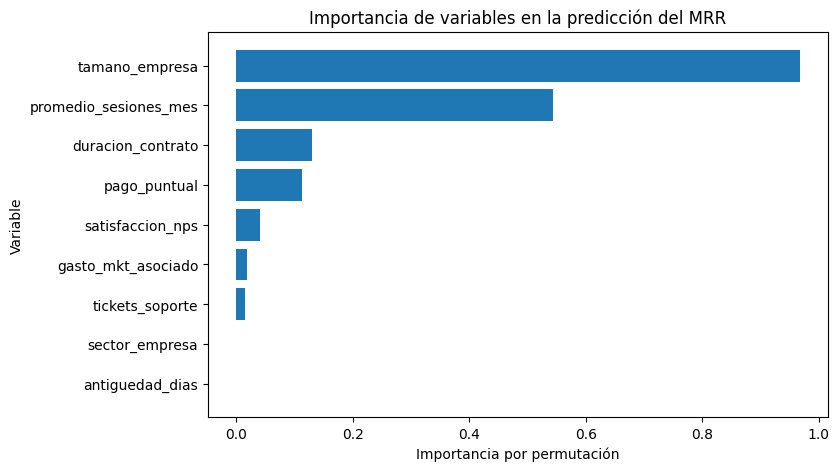

In [27]:
importancia_grafico = importancia_variables.copy()

plt.figure(figsize=(8, 5))

plt.barh(
    importancia_grafico["Variable"],
    importancia_grafico["Importancia"]
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Importancia de variables en la predicción del MRR")

plt.gca().invert_yaxis()
plt.show()

## 5. Conclusiones

Se construyó un modelo de Regresión Lineal para predecir el MRR del próximo trimestre de los clientes de SaaSFlow.

El modelo obtuvo un R² de 0,9240 en el conjunto de prueba, lo que indica que explica aproximadamente el 92,4 % de la variabilidad observada en el MRR futuro. Además, obtuvo un MAE de 68,32 USD, por lo que las predicciones se alejan del valor real en aproximadamente 68 dólares por cliente, en promedio.

Las variables que más contribuyen al desempeño predictivo son `tamano_empresa` y `promedio_sesiones_mes`, seguidas por `duracion_contrato` y `pago_puntual`.

Desde una perspectiva de negocio, estas predicciones podrían utilizarse como apoyo para identificar clientes cuyo ingreso esperado requiera mayor atención y orientar los esfuerzos del equipo de Customer Success.